# **PROJECT 1: Customer Churn Analysis - Telecom Industry** #

## **Columns** ##

Customer churn is a major issue in telecommunications, where retaining customers is significantly more cost-effective than acquiring new ones. \
This dataset contains customer-level details including demographics, services subscribed, billing information, and whether the customer churned.

**CustomerID**: Unique identifier

**Gender**: Male/Female

**SeniorCitizen**: 0 = No, 1 = Yes

**Partner**: Yes/No

**Dependents**: Yes/No

**Tenure**: Number of months with the company

**PhoneService**: Yes/No

**MultipleLines**: Yes/No/No phone service

**InternetService**: DSL/Fiber optic/No

**OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies**: Yes/No/No internet service

**Contract**: Month-to-month/One year/Two year

**PaperlessBilling**: Yes/No

**PaymentMethod**: Electronic check/Mailed check/Bank transfer/Credit card

**MonthlyCharges**: Amount billed monthly

**TotalCharges**: Lifetime total charges

**Churn**: Yes/No


In [51]:
!python.exe -m pip install --upgrade pip
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [52]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [53]:
# Load CSV file
telecom = pd.read_csv('../data/raw/telecom_customer_churn.csv')

In [54]:
# Display basic information on dataset
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset shape: {telecom.shape}")
print(f"Number of customers: {len(telecom)}")
print(f"Number of features: {len(telecom.columns)}")
print("\nFirst 5 rows:\n")
print(telecom.head())
print("\n" + "="*80)

DATASET OVERVIEW
Dataset shape: (7043, 21)
Number of customers: 7043
Number of features: 21

First 5 rows:

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber o

In [55]:
# Data Cleaning and Preprocessing
print("DATA CLEANING AND PREPROCESSING")
print("="*80)

# Check for missing values
print("Missing values per column:\n")
print(telecom.isnull().sum())

DATA CLEANING AND PREPROCESSING
Missing values per column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [56]:
# Handle missing values in TotalCharges (convert to numeric, errors='coerce' will make invalid values NaN)
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

In [57]:
# Fill missing TotalCharges with 0 (likely new customers)
telecom['TotalCharges'].fillna(0, inplace=True)

In [58]:
# Check unique values in categorical columns
categorical_cols = telecom.select_dtypes(include=['object']).columns
print(f"📈 Unique values in categorical columns:\n")
for col in categorical_cols:
    if col != 'customerID':
        print(f"{col}: {telecom[col].unique()[:5]}... ({len(telecom[col].unique())} unique)")

📈 Unique values in categorical columns:

gender: ['Female' 'Male']... (2 unique)
Partner: ['Yes' 'No']... (2 unique)
Dependents: ['No' 'Yes']... (2 unique)
PhoneService: ['No' 'Yes']... (2 unique)
MultipleLines: ['No phone service' 'No' 'Yes']... (3 unique)
InternetService: ['DSL' 'Fiber optic' 'No']... (3 unique)
OnlineSecurity: ['No' 'Yes' 'No internet service']... (3 unique)
OnlineBackup: ['Yes' 'No' 'No internet service']... (3 unique)
DeviceProtection: ['No' 'Yes' 'No internet service']... (3 unique)
TechSupport: ['No' 'Yes' 'No internet service']... (3 unique)
StreamingTV: ['No' 'Yes' 'No internet service']... (3 unique)
StreamingMovies: ['No' 'Yes' 'No internet service']... (3 unique)
Contract: ['Month-to-month' 'One year' 'Two year']... (3 unique)
PaperlessBilling: ['Yes' 'No']... (2 unique)
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']... (4 unique)
Churn: ['No' 'Yes']... (2 unique)


In [59]:
# Handle 'No internet service' and 'No phone service' - convert to 'No'
for col in telecom.columns:
    if telecom[col].dtype == 'object':
        telecom[col] = telecom[col].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

In [60]:
# Create tenure groups
telecom['TenureGroup'] = pd.cut(telecom['tenure'], 
                           bins=[0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120],
                           labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', 
                                  '5-6yr', '6-7yr', '7-8yr', '8-9yr', '9-10yr'])

In [61]:
# Calculate average monthly charge per service
service_columns = ['PhoneService', 'InternetService', 'StreamingTV', 'StreamingMovies']
telecom['ServicesCount'] = telecom[service_columns].apply(lambda x: (x != 'No').sum(), axis=1)
telecom['AvgChargePerService'] = telecom['MonthlyCharges'] / telecom['ServicesCount'].replace(0, 1)

print(f"✅ Final shape: {telecom.shape}")

✅ Final shape: (7043, 24)


In [62]:
# Check data types
print(f"Data types:\n\n{telecom.dtypes}")

Data types:

customerID               object
gender                   object
SeniorCitizen             int64
Partner                  object
Dependents               object
tenure                    int64
PhoneService             object
MultipleLines            object
InternetService          object
OnlineSecurity           object
OnlineBackup             object
DeviceProtection         object
TechSupport              object
StreamingTV              object
StreamingMovies          object
Contract                 object
PaperlessBilling         object
PaymentMethod            object
MonthlyCharges          float64
TotalCharges            float64
Churn                    object
TenureGroup            category
ServicesCount             int64
AvgChargePerService     float64
dtype: object


In [63]:
# Convert SeniorCitizen to categorical for consistency
telecom['SeniorCitizen'] = telecom['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

telecom['SeniorCitizen'].head()

0    No
1    No
2    No
3    No
4    No
Name: SeniorCitizen, dtype: object

In [64]:
# Create a copy for analysis
telecom_clean = telecom.copy()

print(f"Missing values after cleaning: \n\n{telecom_clean.isnull().sum().sum()}")

Missing values after cleaning: 

11


In [65]:
# Churn distribution
print("\n" + "="*80)
print("CHURN DISTRIBUTION ANALYSIS")
print("="*80)

churn_counts = telecom_clean['Churn'].value_counts()
churn_percentage = telecom_clean['Churn'].value_counts(normalize=True) * 100

print(f"Churn Counts:\n\n{churn_counts}")
print(f"\nChurn Percentage:\n\n{churn_percentage.round(2)}")


CHURN DISTRIBUTION ANALYSIS
Churn Counts:

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Text(0.5, 0.98, 'Telecom Customer Churn Analysis Dashboard')

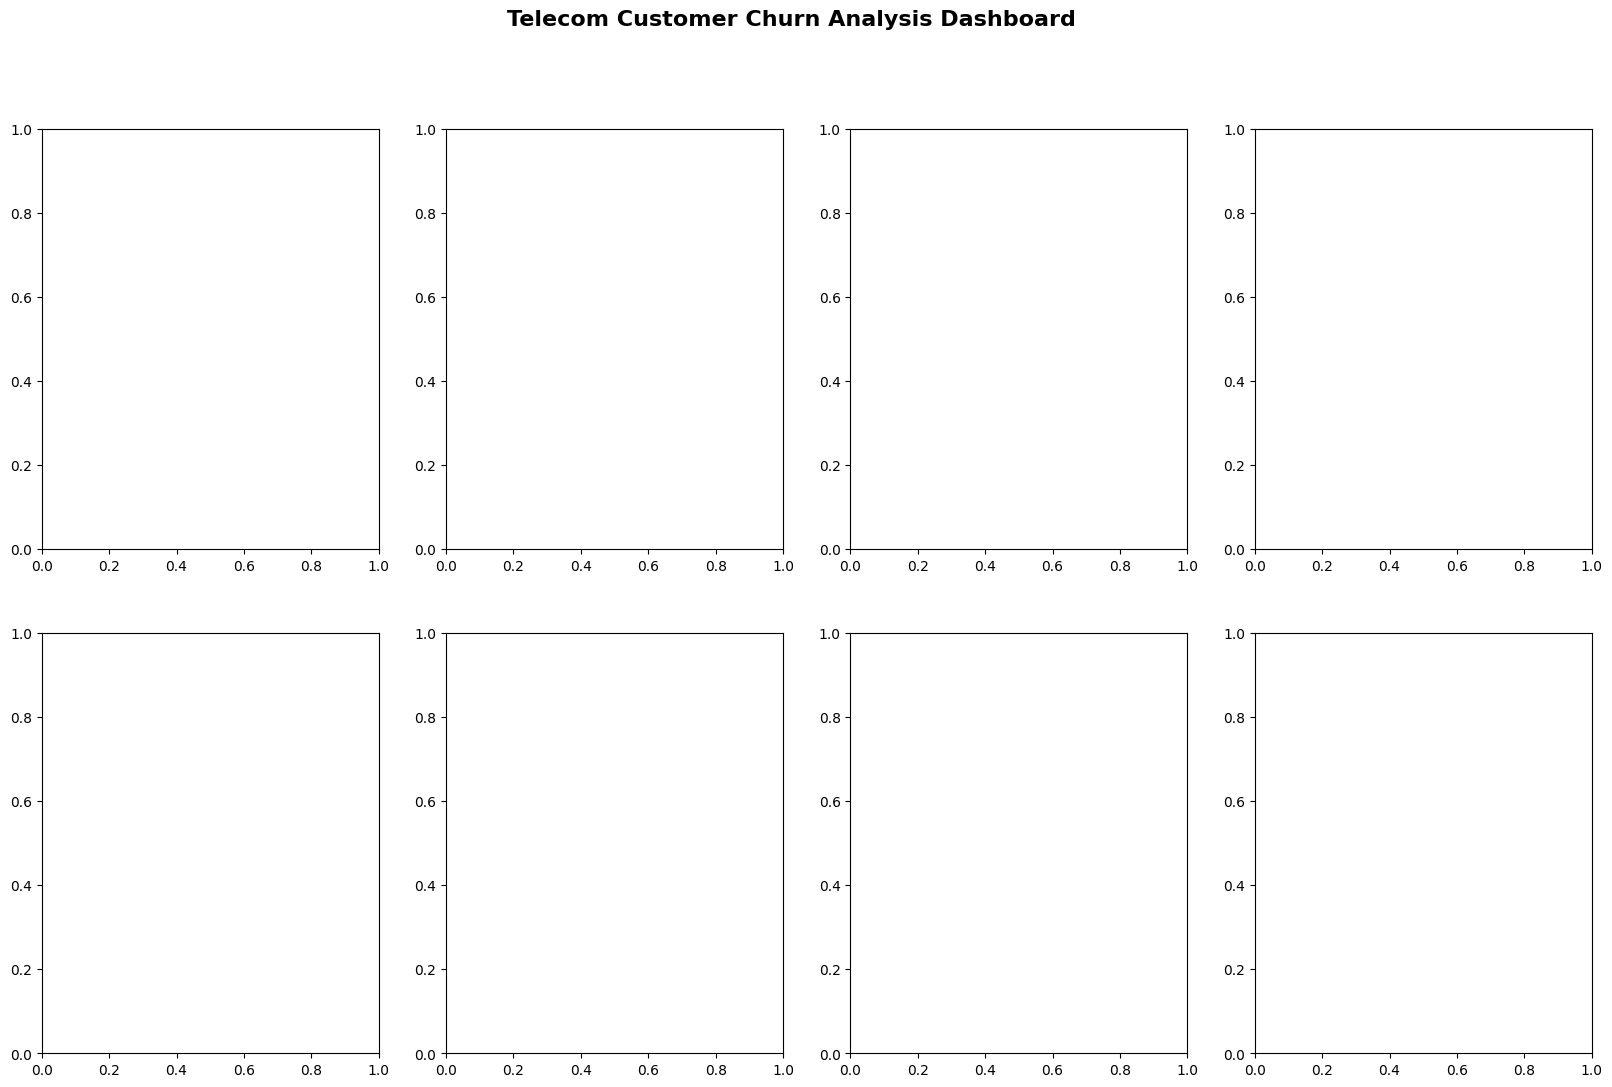

In [66]:
# Create visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle('Telecom Customer Churn Analysis Dashboard', fontsize=16, fontweight='bold')

In [70]:
# Top churn factors (quick analysis)
print("\n3. Top 5 Factors Correlated with Churn:")

# Convert categorical to numerical for correlation
telecom_clean = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include=['object']).columns:
    if col not in ['customerID', 'Churn']:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded['Churn'] = le.fit_transform(df_encoded['Churn'])


3. Top 5 Factors Correlated with Churn:


NameError: name 'df' is not defined

In [67]:
# Drop the customerID column because we have no use for it
telecom_clean = telecom_clean.drop('customerID', axis=1)

telecom_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServicesCount,AvgChargePerService
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,1,29.850
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2-3yr,2,28.475
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,2,26.925
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3-4yr,1,42.300
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,2,35.350


In [69]:
# Create heatmap
sns.heatmap(telecom)
plt.show()

ValueError: could not convert string to float: '7590-VHVEG'

In [ ]:
# 1. Churn Distribution
axes[0, 0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 0].set_title('Churn Distribution', fontweight='bold')

In [ ]:
# 2. Tenure Distribution by Churn
axes[0, 1].hist([telecom_clean[telecom_clean['Churn'] == 'No']['tenure'], 
                telecom_clean[telecom_clean['Churn'] == 'Yes']['tenure']], 
               bins=20, label=['No Churn', 'Churn'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 1].set_xlabel('Tenure (months)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0, 1].legend()

In [ ]:
# 3. Monthly Charges Distribution
axes[0, 2].hist([telecom_clean[telecom_clean['Churn'] == 'No']['MonthlyCharges'], 
                telecom_clean[telecom_clean['Churn'] == 'Yes']['MonthlyCharges']], 
               bins=20, label=['No Churn', 'Churn'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 2].set_xlabel('Monthly Charges ($)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0, 2].legend()

In [ ]:
# 4. Contract Type vs Churn
contract_churn = pd.crosstab(telecom_clean['Contract'], telecom_clean['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[0, 3], color=['#2ecc71', '#e74c3c'])
axes[0, 3].set_xlabel('Contract Type')
axes[0, 3].set_ylabel('Percentage (%)')
axes[0, 3].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 3].tick_params(axis='x', rotation=45)

In [ ]:
# 5. Internet Service vs Churn
internet_churn = pd.crosstab(telecom_clean['InternetService'], telecom_clean['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_xlabel('Internet Service Type')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)